# Demos: Lecture 5

In [1]:
import pennylane as qp
from pennylane import numpy as np

## Exercise 1: One-bit adder

Use a combination of $X$, CNOT, and TOF to create a quantum version of a one-bit adder. Test it in PennyLane on all possible bit values of $a$ and $b$.
 
<img src="fig/half-adder-blank.png" width=300>

In [3]:
dev = qp.device("default.qubit", wires=3)

@qp.qnode(dev)
def one_bit_adder(a, b, wires):
    # Step 1: initialize a and b based on input values
    if a == 1:
        qp.PauliX(wires[0])
    if b == 1:
        qp.PauliX(wires[1])
    # Step 2: perform the addition to create sum and carry bits
    qp.Toffoli([wires[0], wires[1], wires[2]])
    qp.CNOT([wires[0], wires[1]])
    # Step 3: return a meaningful measurement result
    return qp.probs()

In [4]:
one_bit_adder(1, 1, [0, 1, 2])

array([0., 0., 0., 0., 0., 1., 0., 0.])

## Exercise 2: Controlled addition

Using your adder from earlier, implement a circuit in PennyLane that uses `qp.ctrl` to perform addition if the control qubit is in state $|0\rangle$, and flip the state of the control qubit if the carry bit is 1.

<img src="fig/controlled_add.png" width=300>

In [12]:
def one_bit_adder_subroutine(wires):
    qp.Toffoli([wires[0], wires[1], wires[2]])
    qp.CNOT([wires[0], wires[1]])

In [15]:
dev = qp.device("default.qubit", wires=4, shots=1)

@qp.qnode(dev)
def controlled_add(x, a, b, wires):
    if a == 1:
        qp.PauliX(wires[1])
    if b == 1:
        qp.PauliX(wires[2])

    if x == 1:
        qp.PauliX(wires[0])

    control_function = qp.ctrl(one_bit_adder_subroutine, control=wires[0], control_values=[0])
    control_function([1, 2, 3])

    qp.CNOT([wires[3], wires[0]])

    return qp.sample()

(<Figure size 900x500 with 1 Axes>, <Axes: >)

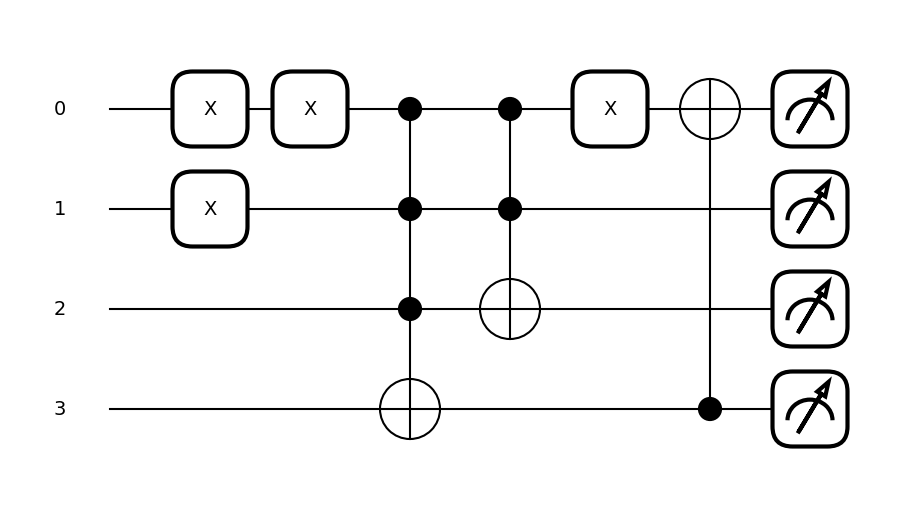

In [16]:
qp.draw_mpl(controlled_add)(1, 1, 0, [0, 1, 2, 3])